

```
🟦 DAY 17 — VECTOR DATABASES

1. GENAI — 60 MIN
□ What is a Vector Database?
□ Understanding Embeddings & Vector Spaces
□ Similarity Search (Cosine, Euclidean, Dot Product)
□ Set up a local/cloud Vector DB (e.g., ChromaDB or Pinecone)
□ Store & query 5 document embeddings

2. DSA — 45 MIN
□ Graphs: Dijkstra's Algorithm
□ Graphs: Topological Sort
□ Solve 2 problems

3. PRACTICE — 15 MIN
□ Perform a semantic search query
□ Compare keyword search vs. vector similarity results
```



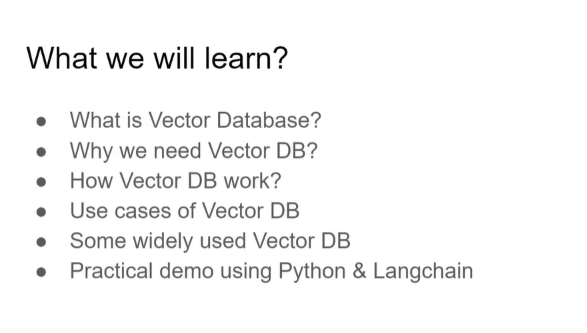

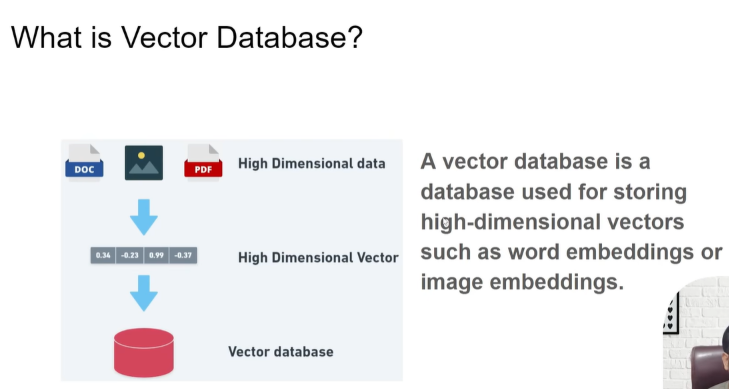

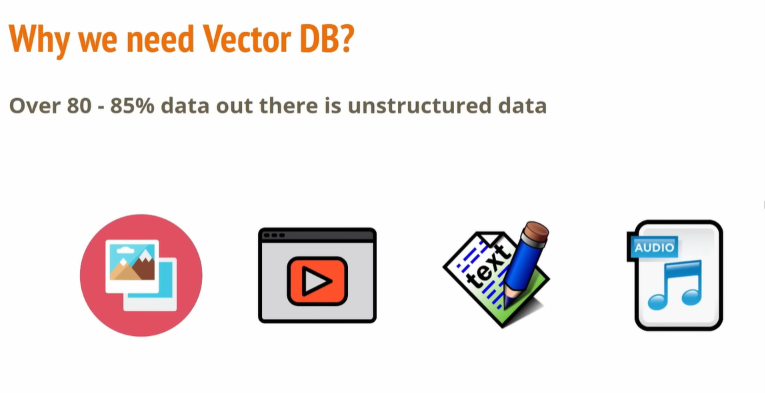

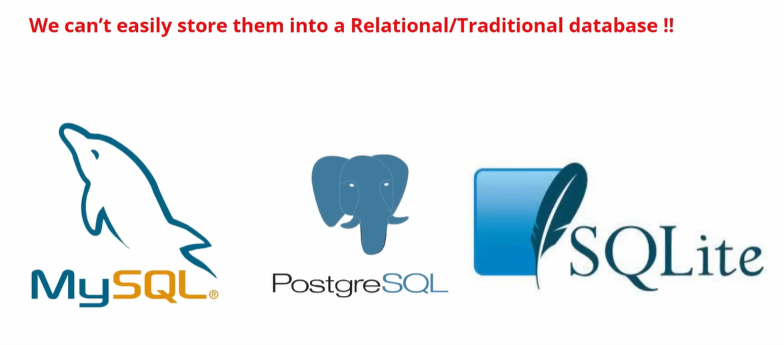

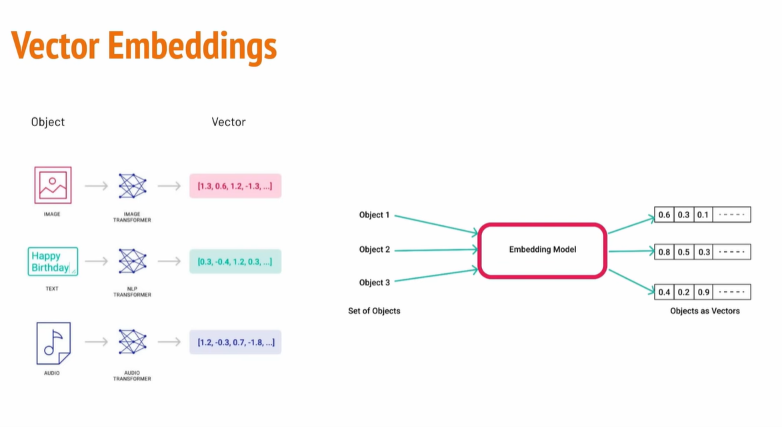

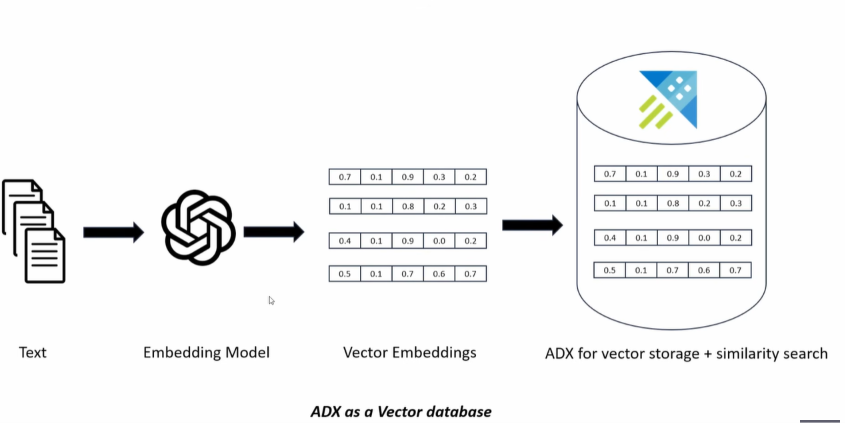

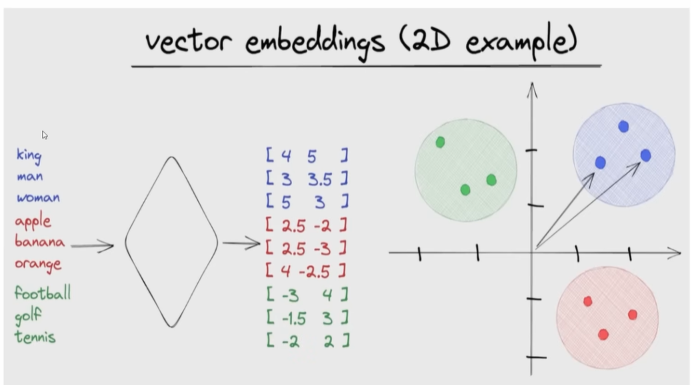

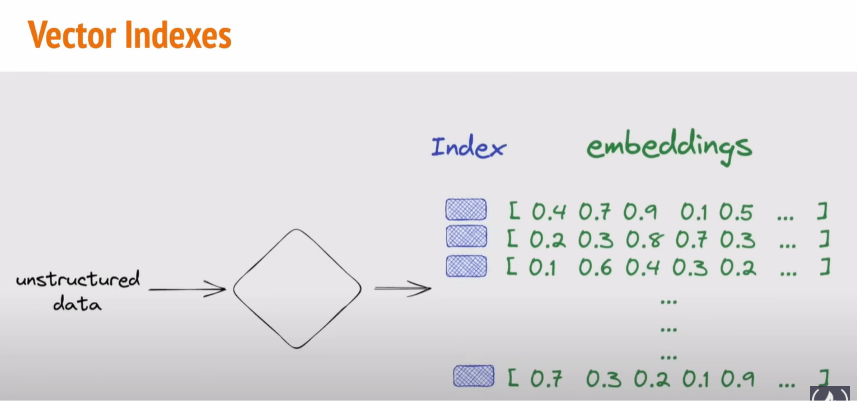

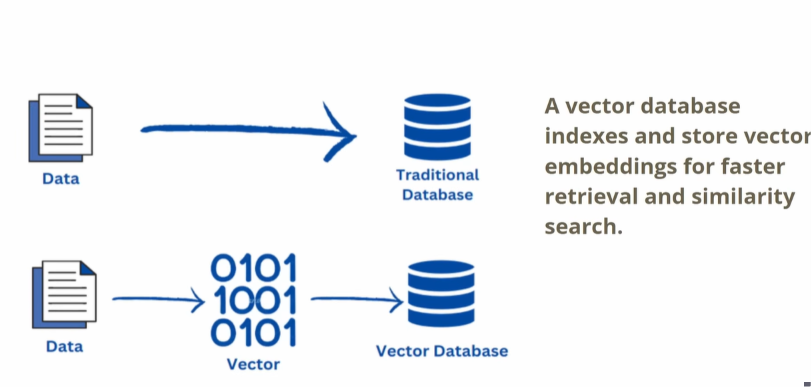

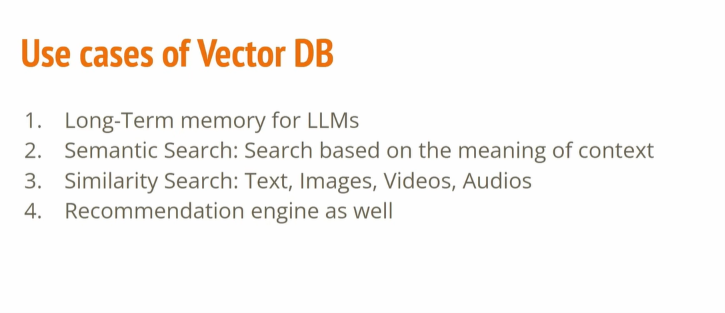

<br>
<br>

### **CHROMADB**

In [1]:
!pip -q install chromadb openai langchain langchain-chroma tiktoken

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 79.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 28.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 122.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.1/23.1 MB 87.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.2/137.2 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.6/204.6 kB 18.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.7/95.7 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.4/69.4 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 5.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently 

In [2]:
#CHECK THE VERSION
!pip show chromadb

Name: chromadb
Version: 1.5.9
Summary: Chroma.
Home-page: https://github.com/chroma-core/chroma
Author: 
Author-email: Jeff Huber <jeff@trychroma.com>, Anton Troynikov <anton@trychroma.com>
License: 
Location: /usr/local/lib/python3.13/dist-packages
Requires: bcrypt, build, grpcio, httpx, importlib-resources, jsonschema, kubernetes, mmh3, numpy, onnxruntime, opentelemetry-api, opentelemetry-exporter-otlp-proto-grpc, opentelemetry-sdk, orjson, overrides, pybase64, pydantic, pydantic-settings, pypika, pyyaml, rich, tenacity, tokenizers, tqdm, typer, typing-extensions, uvicorn
Required-by: langchain-chroma


In [3]:
# Download the zip file properly
!wget -q -O new_articles.zip "https://www.dropbox.com/scl/fi/p7d0zjnrefjne94j3ec2b/new_articles.zip?rlkey=izy5z44eofgx5fmjn8tif4y99&dl=1"

In [4]:
# Unzip the downloaded file into the directory
!unzip -q -o new_articles.zip -d new_articles

In [ ]:
!pip -q install langchain-chroma langchain-openai langchain-community langchain-text-splitters

#### SETTING UP ENVIRONMENT

In [23]:
import os
from google.colab import userdata
import getpass

# Attempt to get from Colab Secrets
try:
    api_key = userdata.get('OPENAI_API_KEY')
    base_url = userdata.get('OPENAI_API_BASE', 'https://api.openai.com/v1')
    os.environ["OPENAI_API_KEY"] = api_key
    os.environ["OPENAI_API_BASE"] = base_url
    print(f"✅ API Key loaded. Base URL: {base_url}")
except Exception:
    os.environ["OPENAI_API_KEY"] = getpass.getpass("Please paste your API Key: ")
    os.environ["OPENAI_API_BASE"] = input("Please enter your API Base URL (default: https://api.openai.com/v1): ") or "https://api.openai.com/v1"
    print("✅ Environment variables set for this session.")

Please paste your API Key: ··········
Please enter your API Base URL (default: https://api.openai.com/v1): "https://integrate.api.nvidia.com/v1"
✅ Environment variables set for this session.


In [7]:
import sys
import os

# Ensure all necessary langchain components are installed
!{sys.executable} -m pip install -q langchain-chroma langchain-openai langchain-community

from langchain_chroma import Chroma
from langchain_openai import OpenAIEmbeddings, OpenAI
from langchain_community.document_loaders import DirectoryLoader, TextLoader

# Re-download and unzip to ensure files are present
if not os.path.exists("./new_articles"):
    print("Downloading and extracting data...")
    !wget -q -O new_articles.zip "https://www.dropbox.com/scl/fi/p7d0zjnrefjne94j3ec2b/new_articles.zip?rlkey=izy5z44eofgx5fmjn8tif4y99&dl=1"
    !unzip -q -o new_articles.zip -d new_articles

path = "./new_articles/"
loader = DirectoryLoader(path, glob="**/*.txt", loader_cls=TextLoader)
docs = loader.load()

print(f"Successfully loaded {len(docs)} documents.")

Successfully loaded 21 documents.


In [8]:
docs

[Document(metadata={'source': 'new_articles/05-03-ai-replace-tv-writers-strike.txt'}, page_content='In the must-watch final season of “Succession,” Kendall Roy enters a conference room with his siblings. As the scene opens, he takes a seat and declares: “Who will be the successor? Me.”\n\nOf course, that scene didn’t appear on HBO’s hit show, but it’s a good illustration of generative AI’s level of sophistication compared to the real thing. Yet as the Writers Guild of America goes on strike in pursuit of livable working conditions and better streaming residuals, the networks won’t budge on writers’ demands to regulate the use of AI in writers’ rooms.\n\n“Our proposal is that we not be required to adapt something that’s output by AI, and that the output of an AI not be considered writers’ work,” comedy writer Adam Conover told TechCrunch. “That doesn’t entirely exclude that technology from the production process, but it does mean that our working conditions wouldn’t be undermined by AI.

In [12]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

In [13]:
text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
texts = text_splitter.split_documents(docs)

print(f"Created {len(texts)} chunks from {len(docs)} documents.")

Created 233 chunks from 21 documents.


In [24]:
persist_directory = 'db'

# Initialize embeddings with the custom model and base URL
embedding_function = OpenAIEmbeddings(
    model="gpt-oss-120b",
    openai_api_base=os.environ.get("OPENAI_API_BASE")
)

# Create and persist the vector database
vectordb = Chroma.from_documents(
    documents=texts,
    embedding=embedding_function,
    persist_directory=persist_directory
)

print(f"Vector database successfully created with {len(texts)} chunks using gpt-oss-120b.")

### **Persisting the Database**

Here is what each line in the next cell does:

*   **`vectordb.persist()`**: This command saves (writes) the current state of the vector database to the disk in the `persist_directory` we defined earlier (`db`). This ensures your embeddings aren't lost when the session ends.
*   **`vectordb = None`**: This clears the variable from memory, effectively closing the connection to the database. This is a good practice to prevent file locking issues if you need to reload it later.

In [ ]:
#persist db to the disk
vectordb.persist()
vectordb = None

### **Retrieving and Querying**

To use the database again, we reload it from the disk and create a `retriever` interface.

In [ ]:
# Reload the database from the disk
vectordb = Chroma(
    persist_directory=persist_directory,
    embedding_function=embedding_function
)

# Create a retriever object
# 'search_kwargs={"k": 3}' tells the retriever to get the top 3 most relevant chunks
retriever = vectordb.as_retriever(search_kwargs={"k": 3})

# Perform a test retrieval
query = "What is the Writers Guild of America striking for?"
docs_retrieved = retriever.get_relevant_documents(query)

# Display results
for i, doc in enumerate(docs_retrieved):
    print(f"\n--- Result {i+1} ---")
    print(doc.page_content[:300] + "...")

### **Question Answering Chain**

We will use the `RetrievalQA` chain to combine the retriever with an LLM for answering queries.

In [ ]:
from langchain.chains import RetrievalQA

# Initialize the LLM (using the same custom base URL if provided)
llm = OpenAI(model_name="gpt-oss-120b")

# Create the QA chain
qa_chain = RetrievalQA.from_chain_type(
    llm=llm,
    chain_type="stuff",
    retriever=retriever,
    return_source_documents=True
)

# Function to process and display the answer
def process_llm_response(llm_response):
    print(f"Answer: {llm_response['result']}")
    print("\nSources:")
    for source in llm_response["source_documents"]:
        print(source.metadata['source'])

# Test Query
query = "What are the main demands of the Writers Guild of America?"
print(f"Query: {query}\n")
llm_response = qa_chain.invoke(query)
process_llm_response(llm_response)

### **Deleting the Database**

To completely remove the vector database, we first need to ensure the connection is closed and then delete the physical directory.

In [ ]:
import shutil

# 1. Clear the variable to close the database connection
vectordb = None

# 2. Delete the directory from the local file system
if os.path.exists(persist_directory):
    shutil.rmtree(persist_directory)
    print(f"Successfully deleted the database directory: '{persist_directory}'")
else:
    print(f"The directory '{persist_directory}' does not exist.")

In [ ]:
import shutil
import os

# 1. Close connection
vectordb = None

# 2. Delete the folder
if os.path.exists('db'):
    shutil.rmtree('db')
    print("Database 'db' deleted successfully.")



---



###### **ADITHYA UBALE**